In [2]:
import pandas as pd
import numpy as np
root="/home/jacoponudo/Documents/Virality-on-Shorts/" # TO CHANGE according to your local path

# Carichiamo i dataset puliti
instagram = pd.read_csv(root + "data/clean/instagram.csv")
tiktok = pd.read_csv(root + "data/clean/tiktok.csv")
youtube = pd.read_csv(root + "data/clean/youtube.csv")

# Filtriamo i publisher attivi per ogni piattaforma
from tools import filter_active_publisher_years
youtube_active, yt_publishers, yt_counts = filter_active_publisher_years(
    df=youtube,
    platform_name="YouTube",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=70
)

instagram_active, ig_publishers, ig_counts = filter_active_publisher_years(
    df=instagram,
    platform_name="Instagram",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=70
)

tiktok_active, tt_publishers, tt_counts = filter_active_publisher_years(
    df=tiktok,
    platform_name="TikTok",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=70
)


# Selezioniamo le colonne di interesse
tiktok=tiktok_active[['video_id','publisher', 'year','views','platform']]
youtube=youtube_active[['video_id','publisher', 'year','views','platform']]
instagram=instagram_active[['video_id','publisher', 'year','views','platform']]

tiktok['views'] =np.log(tiktok['views'].astype(int) + 1)
youtube['views'] =np.log(youtube['views'].astype(int) + 1)
instagram['views'] =np.log(instagram['views'].astype(int) + 1)


YouTube
-------
Original videos:              51,863
Original publishers:          130
Videos after filtering:       47,185
Unique publishers retained:   53

Publisher-years retained by year:
year
2022     8
2023    17
2024    24
2025    42
2026    39
Name: count, dtype: int64

Instagram
---------
Original videos:              235,743
Original publishers:          161
Videos after filtering:       227,976
Unique publishers retained:   130

Publisher-years retained by year:
year
2022     30
2023     97
2024    103
2025    121
2026    103
Name: count, dtype: int64

TikTok
------
Original videos:              195,672
Original publishers:          160
Videos after filtering:       189,948
Unique publishers retained:   119

Publisher-years retained by year:
year
2022    28
2023    60
2024    76
2025    94
2026    86
Name: count, dtype: int64


Preview of channel-year summary table:
    platform  publisher  year  n_videos_original  ratio_mean  ratio_ci_low  \
0  Instagram      AMICA  2023                101    1.306298      0.862384   
1  Instagram      AMICA  2024                189    1.160922      0.815712   
2  Instagram      AMICA  2025                243    1.091807      0.832230   
3  Instagram      AMICA  2026                103    1.677852      1.327165   
4  Instagram  Adnkronos  2023                128    1.277565      1.055438   

   ratio_ci_high  
0       1.624400  
1       1.815159  
2       1.529381  
3       2.040248  
4       1.525749  

Total channel-years analyzed: 928
Percentile alto usato: P80 | Percentile basso: P20

OPTION A - Quantile Ratio (P80 - P20, log scale)
            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   ratio_mean
No. Observations:   928       Method:               REML      
No. Groups:         285       Scale:                0.3534    
Min

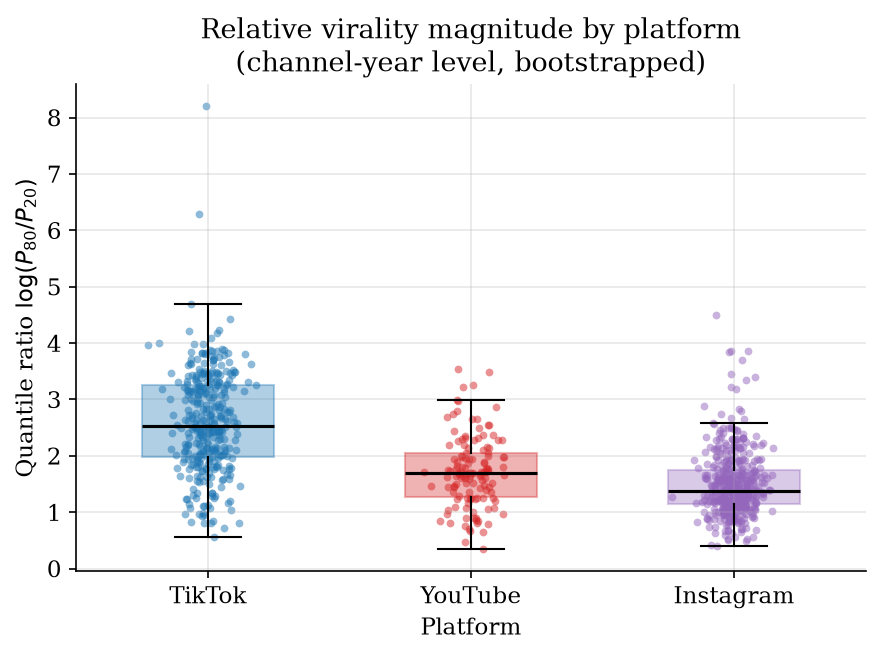

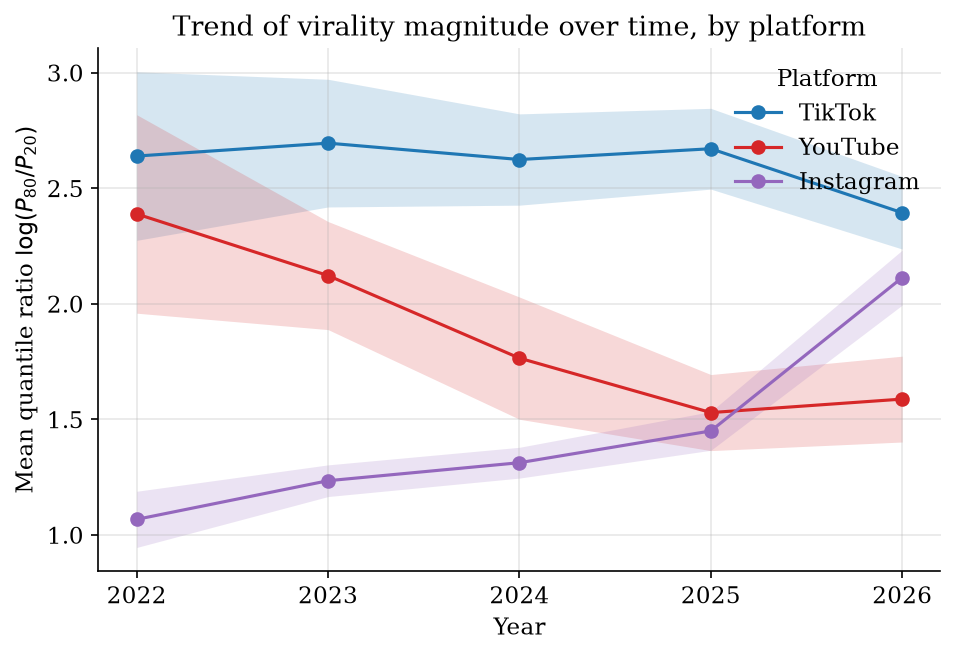

In [4]:
"""
Option A - Quantile Ratio (relative magnitude of virality)
============================================================
Metric: ratio_mean = P{Q_HIGH} - P{Q_LOW} (log scale)
Since log_views is already natural-log transformed, this difference
equals log(P_high / P_low) in the original views scale: how "explosive"
the upper tail is relative to the channel's typical video.

Bootstrap rationale
--------------------
Channels have different numbers of videos per year (>=70, but not
equal). Tail quantiles are sensitive to sample size, so we resample
with replacement to a fixed N=100 per channel-year, repeated B=100
times, and average. This makes the metric comparable "at equal
exposure" across channels/platforms.

Expected input
--------------
tiktok, youtube, instagram: DataFrames with columns
  ['video_id', 'publisher', 'year', 'views', 'platform']
where 'views' is already np.log(views + 1).

Plots (for paper)
-----------------
Fig. 1: Boxplot of ratio_mean by platform -> distribution comparison
Fig. 2: ratio_mean vs n_videos_original by platform -> confound check
Fig. 3: ratio_mean trend over year by platform (mean +/- 95% CI)
"""

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

np.random.seed(42)

N_BOOT = 100
B_REPLICATES = 100

# --- Parametro iniziale: percentile più alto usato nel quantile ratio ---
Q_HIGH = 0.80      # percentile alto (es. 0.95 = P95)
Q_LOW = 0.20       # percentile basso di riferimento (mediana)

FIGURE_DIR = "figures_A"

# ----------------------------------------------------------------------
# Publication-style matplotlib settings
# ----------------------------------------------------------------------
PLATFORM_COLORS = {
    "TikTok": "#1f77b4",
    "YouTube": "#d62728",
    "Instagram": "#9467bd",
}

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "legend.frameon": False,
})


def quantile_ratio(x, q_high=Q_HIGH, q_low=Q_LOW):
    """P_high - P_low in log scale = log(P_high / P_low) in original scale."""
    return np.quantile(x, q_high) - np.quantile(x, q_low)


def bootstrap_quantile_ratio(all_data, q_high=Q_HIGH, q_low=Q_LOW):
    records = []
    for key, grp in all_data.groupby("group_key"):
        views = grp["log_views"].values
        platform = grp["platform"].iloc[0]
        publisher = grp["publisher"].iloc[0]
        year = grp["year"].iloc[0]
        n_original = len(views)

        ratio_boot = []
        for _ in range(B_REPLICATES):
            sample = np.random.choice(views, size=N_BOOT, replace=True)
            ratio_boot.append(quantile_ratio(sample, q_high=q_high, q_low=q_low))

        records.append({
            "platform": platform,
            "publisher": publisher,
            "year": year,
            "n_videos_original": n_original,
            "ratio_mean": np.mean(ratio_boot),
            "ratio_ci_low": np.percentile(ratio_boot, 2.5),
            "ratio_ci_high": np.percentile(ratio_boot, 97.5),
        })
    return pd.DataFrame(records)


def _platform_order(summary):
    """Consistent platform ordering/colors across all figures."""
    preferred = [p for p in ["TikTok", "YouTube", "Instagram"] if p in summary["platform"].unique()]
    return preferred or sorted(summary["platform"].unique())


def _color_for(platform):
    return PLATFORM_COLORS.get(platform, "#7f7f7f")


def _quantile_label(q_high=Q_HIGH, q_low=Q_LOW):
    """Etichetta LaTeX per l'asse, es. 'P_{95}/P_{50}' se q_high=0.95."""
    return r"$\log(P_{%d}/P_{%d})$" % (round(q_high * 100), round(q_low * 100))


def plot_boxplot_by_platform(summary, out_dir, q_high=Q_HIGH, q_low=Q_LOW):
    """Fig. 1: distribution of ratio_mean by platform (boxplot + jittered points)."""
    platforms = _platform_order(summary)
    fig, ax = plt.subplots(figsize=(6, 4.5))

    data = [summary.loc[summary["platform"] == p, "ratio_mean"].values for p in platforms]
    bp = ax.boxplot(
        data,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.5},
    )
    # Set tick labels manually (avoids the 'labels'/'tick_labels' kwarg
    # rename across matplotlib versions: removed in 3.9+, renamed in 3.11+)
    ax.set_xticks(range(1, len(platforms) + 1))
    ax.set_xticklabels(platforms)
    for patch, p in zip(bp["boxes"], platforms):
        patch.set_facecolor(_color_for(p))
        patch.set_alpha(0.35)
        patch.set_edgecolor(_color_for(p))

    rng = np.random.default_rng(0)
    for i, (p, vals) in enumerate(zip(platforms, data), start=1):
        jitter = rng.normal(0, 0.06, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=_color_for(p), alpha=0.5, s=14, linewidths=0)

    ax.set_ylabel(f"Quantile ratio {_quantile_label(q_high, q_low)}")
    ax.set_xlabel("Platform")
    ax.set_title("Relative virality magnitude by platform\n(channel-year level, bootstrapped)")

    fig.tight_layout()
    fig.show()
    fig.show()




def plot_ratio_trend_by_year(summary, out_dir, q_high=Q_HIGH, q_low=Q_LOW):
    """Fig. 3: yearly mean ratio_mean +/- 95% CI, by platform."""
    platforms = _platform_order(summary)
    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    for p in platforms:
        sub = summary[summary["platform"] == p].copy()
        sub["year"] = sub["year"].astype(int)
        grouped = sub.groupby("year")["ratio_mean"].agg(["mean", "std", "count"]).reset_index()
        grouped["se"] = grouped["std"] / np.sqrt(grouped["count"])
        grouped["ci95"] = 1.96 * grouped["se"]
        grouped = grouped.sort_values("year")

        ax.plot(grouped["year"], grouped["mean"], marker="o", color=_color_for(p), label=p)
        ax.fill_between(
            grouped["year"],
            grouped["mean"] - grouped["ci95"],
            grouped["mean"] + grouped["ci95"],
            color=_color_for(p), alpha=0.18, linewidth=0,
        )

    ax.set_xlabel("Year")
    ax.set_ylabel(f"Mean quantile ratio {_quantile_label(q_high, q_low)}")
    ax.set_title("Trend of virality magnitude over time, by platform")
    ax.set_xticks(sorted(summary["year"].astype(int).unique()))
    ax.legend(title="Platform", loc="best")

    fig.tight_layout()
    fig.show()


def generate_plots(summary, out_dir=FIGURE_DIR, q_high=Q_HIGH, q_low=Q_LOW):
    os.makedirs(out_dir, exist_ok=True)
    plot_boxplot_by_platform(summary, out_dir, q_high=q_high, q_low=q_low)
    plot_ratio_trend_by_year(summary, out_dir, q_high=q_high, q_low=q_low)
    print(f"\nSaved 3 figures (PDF + PNG) to '{out_dir}/'")


def main(q_high=Q_HIGH, q_low=Q_LOW):

    all_data = pd.concat([tiktok, youtube, instagram], ignore_index=True)
    all_data = all_data.rename(columns={"views": "log_views"})
    all_data["group_key"] = (
        all_data["platform"].astype(str) + "_" +
        all_data["publisher"].astype(str) + "_" +
        all_data["year"].astype(str)
    )

    # --- 2. Bootstrap the quantile-ratio metric per channel-year ---
    summary = bootstrap_quantile_ratio(all_data, q_high=q_high, q_low=q_low)
    summary["year"] = summary["year"].astype(str)

    print("Preview of channel-year summary table:")
    print(summary.head())
    print(f"\nTotal channel-years analyzed: {len(summary)}")
    print(f"Percentile alto usato: P{round(q_high*100)} | Percentile basso: P{round(q_low*100)}")

    # --- 3. Mixed model: ratio ~ platform + year + activity, random effect per channel ---
    model_E = smf.mixedlm(
        "ratio_mean ~ platform + year + n_videos_original",
        data=summary,
        groups=summary["publisher"],
    ).fit()

    print("\n" + "=" * 70)
    print(f"OPTION A - Quantile Ratio (P{round(q_high*100)} - P{round(q_low*100)}, log scale)")
    print("=" * 70)
    print(model_E.summary())


    print("\nSaved: virality_option_a_summary.csv")

    # --- 4. Plots for the paper ---
    generate_plots(summary, q_high=q_high, q_low=q_low)


if __name__ == "__main__":
    main(q_high=Q_HIGH, q_low=Q_LOW)